In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Set dark background style
plt.style.use('dark_background')

In [58]:
df = pd.read_csv('../data/raw/telco-customer-churn.csv')

In [59]:
# basic info about dataset
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [60]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Let's see why TotalCharges is dtype object, even though it appears as float and have no null values**

In [61]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


❗**There were 11 non-numeric values, now as NaN, later we can use Mean/Median Imputation to fix this**
- but now we know we have to check for blank spaces in the transform step when receiving data for prediction

In [62]:
# let's see which column is a yes or no column or at least has the potential to be after some transforming
for col in df.columns:
    uniques = df[col].unique()
    print(f"{col}: {uniques[:5]}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 42.3  70.7 ]
TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65]
Churn: ['No' 'Yes']


- MultipleLines: PhoneService already tell if there's phone service, so the 'No phone service' option can become 'No'
- OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies: InternetService already tell if there's internet service, so 'No internet service' can become 'No'

we will apply the changes mentioned above and map the yes/no columns to 1/0

#### Target analysis

In [63]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

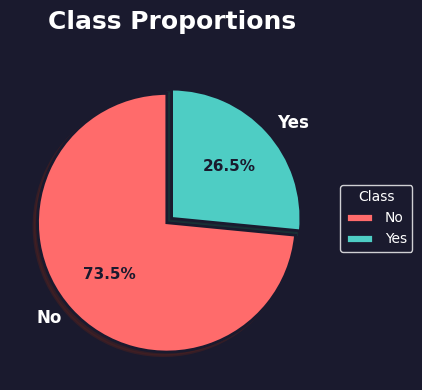


Ratio: 0.36


In [64]:
categories = ['No', 'Yes']
values = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#1a1a2e')  
ax.set_facecolor('#1a1a2e')

colors = ['#ff6b6b', '#4ecdc4']

wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    explode=(0.05, 0),
    shadow=True,
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2}
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_color('#1a1a2e')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Class Proportions', fontsize=18, fontweight='bold', 
             color='white', pad=20)

ax.legend(wedges, categories, title="Class", loc="center left", 
          bbox_to_anchor=(1, 0, 0.5, 1), facecolor='#1a1a2e', 
          edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

ratio = values.min() / values.max()
print(f"\nRatio: {ratio:.2f}")

❗**some research showed this class ratio is considered mild, no re-balance needed, use class_weight='balanced' in baseline classifier tests to look for diferences**

#### data transformation
transforming data for further analysis

In [65]:
# imputation for TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
# making some columns binary
df['MultipleLines'] = df['MultipleLines'].apply(lambda value: 'No' if value=='No phone service' else value)
columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columns:
    df[col] = df[col].apply(lambda value: 'No' if value=='No internet service' else value)

In [66]:
# converting no-yes columns to 0-1 (also female-male, alphabetical order so 0-1)
mapping = {'Yes': True, 'No': False, 'Male': True, 'Female': False}
no_yes_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'Churn'] + columns
df[no_yes_cols] = df[no_yes_cols].map(lambda value: mapping[value])
# senior citizen to bool
df['SeniorCitizen'] = df['SeniorCitizen'].apply(lambda value: bool(value))

In [67]:
# one-hot encoding for the rest
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   bool   
 2   SeniorCitizen                          7043 non-null   bool   
 3   Partner                                7043 non-null   bool   
 4   Dependents                             7043 non-null   bool   
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   bool   
 7   MultipleLines                          7043 non-null   bool   
 8   OnlineSecurity                         7043 non-null   bool   
 9   OnlineBackup                           7043 non-null   bool   
 10  DeviceProtection                       7043 non-null   bool   
 11  Tech

In [69]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,False,False,True,False,1,False,False,False,True,...,29.85,29.85,False,False,False,False,False,False,True,False
1,5575-GNVDE,True,False,False,False,34,True,False,True,False,...,56.95,1889.50,False,False,False,True,False,False,False,True
2,3668-QPYBK,True,False,False,False,2,True,False,True,True,...,53.85,108.15,True,False,False,False,False,False,False,True
3,7795-CFOCW,True,False,False,False,45,False,False,True,False,...,42.30,1840.75,False,False,False,True,False,False,False,False
4,9237-HQITU,False,False,False,False,2,True,False,False,False,...,70.70,151.65,True,True,False,False,False,False,True,False


In [70]:
# persist
df.to_csv("../data/interim/telco_customer_churn_preprocessed.csv", index=False)

### MVP and baselines

In [1]:
import warnings
import pandas as pd
from sklearn.model_selection import train_test_split
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from mlflow.models import infer_signature

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

RANDOM_SEED = 19

df = pd.read_csv("../data/interim/telco_customer_churn_preprocessed.csv")

In [2]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
# Create evaluation dataset
eval_data = X_test.copy()
eval_data["Churn"] = y_test
df_train = pd.concat([X_train, y_train], axis=1)

In [3]:
mlflow.create_experiment(
    name="telco_churn_classification",
    artifact_location="../artifacts"
)

mlflow.set_experiment("telco_churn_classification")

2026/03/23 22:33:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/23 22:33:11 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='/workspaces/fiap-tech-challenge-fase-1/notebooks/../artifacts', creation_time=1774305192141, experiment_id='1', last_update_time=1774305192141, lifecycle_stage='active', name='telco_churn_classification', tags={}, workspace='default'>

In [4]:
# unbalanced
with mlflow.start_run(run_name="logistic unbalanced no scaling"):
    dataset_train = mlflow.data.from_pandas(
        df_train, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_train, context="training")

    dataset_test = mlflow.data.from_pandas(
        eval_data, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_test, context="test")

    model = LogisticRegression(random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    # Log model
    signature = infer_signature(X_test, model.predict(X_test))
    model_info = mlflow.sklearn.log_model(model, name="LogisticRegressionUnbalanced", signature=signature)
    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets="Churn",
        model_type="classifier",
    )

2026/03/23 22:33:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 22:33:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 22:33:16 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-46137c3fae6f4f94bc326bd3aaf20077
2026/03/23 22:33:16 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/03/23 22:33:16 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is True, negat

<Figure size 1050x700 with 0 Axes>

In [5]:
result.metrics

{'score': 0.8019872249822569,
 'true_negatives': np.int64(933),
 'false_positives': np.int64(101),
 'false_negatives': np.int64(178),
 'true_positives': np.int64(197),
 'example_count': 1409,
 'accuracy_score': 0.8019872249822569,
 'recall_score': 0.5253333333333333,
 'precision_score': 0.6610738255033557,
 'f1_score': 0.5854383358098069,
 'log_loss': 0.4078868563193173,
 'roc_auc': 0.8537640232108317,
 'precision_recall_auc': 0.6599462279029147}

In [6]:
# balanced
with mlflow.start_run(run_name="logistic balanced no scaling"):
    dataset_train = mlflow.data.from_pandas(
        df_train, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_train, context="training")

    dataset_test = mlflow.data.from_pandas(
        eval_data, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_test, context="test")

    model = LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced')
    model.fit(X_train, y_train)
    # Log model
    signature = infer_signature(X_test, model.predict(X_test))
    model_info = mlflow.sklearn.log_model(model, name="LogisticRegressionBalanced", signature=signature)
    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets="Churn",
        model_type="classifier",
    )

2026/03/23 22:33:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 22:33:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 22:33:25 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-8b3b3d1758764a0a861814ffc3628027
2026/03/23 22:33:25 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/03/23 22:33:25 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is True, negat

In [7]:
result.metrics

{'score': 0.7565649396735273,
 'true_negatives': np.int64(767),
 'false_positives': np.int64(267),
 'false_negatives': np.int64(76),
 'true_positives': np.int64(299),
 'example_count': 1409,
 'accuracy_score': 0.7565649396735273,
 'recall_score': 0.7973333333333333,
 'precision_score': 0.5282685512367491,
 'f1_score': 0.6354941551540914,
 'log_loss': 0.46943532884057493,
 'roc_auc': 0.8563894261766601,
 'precision_recall_auc': 0.6628296683102483}

In [8]:
#Dummy
with mlflow.start_run(run_name="dummy classifier no scaling"):
    dataset_train = mlflow.data.from_pandas(
        df_train, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_train, context="training")

    dataset_test = mlflow.data.from_pandas(
        eval_data, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn", targets="Churn"
    )
    mlflow.log_input(dataset_test, context="test")

    model = DummyClassifier(random_state=RANDOM_SEED)
    model.fit(X_train, y_train)
    # Log model
    signature = infer_signature(X_test, model.predict(X_test))
    model_info = mlflow.sklearn.log_model(model, name="DummyClassifier", signature=signature)
    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets="Churn",
        model_type="classifier",
    )

2026/03/23 22:33:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 22:33:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 22:33:36 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-cc2242c8d4104cc08320c7d55392ed30
2026/03/23 22:33:36 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/03/23 22:33:36 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is True, negat

In [9]:
result.metrics

{'score': 0.7338537970191625,
 'true_negatives': np.int64(1034),
 'false_positives': np.int64(0),
 'false_negatives': np.int64(375),
 'true_positives': np.int64(0),
 'example_count': 1409,
 'accuracy_score': 0.7338537970191625,
 'recall_score': 0.0,
 'precision_score': 0.0,
 'f1_score': 0.0,
 'log_loss': 0.5793903918529225,
 'roc_auc': 0.5,
 'precision_recall_auc': 0.26614620298083747}

**I'd forgotten to do feature scaling at first but decided to evaluate like that to see the difference, now let's do it**

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df = pd.read_csv("../data/interim/telco_customer_churn_preprocessed.csv")

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']])
X_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(X_test[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Create evaluation dataset
eval_data = X_test.copy()
eval_data["Churn"] = y_test
# dataset to log
df_train = pd.concat([X_train, y_train], axis=1)

In [ ]:
# scaled balanced
with mlflow.start_run(run_name="logistic balanced"):
    dataset_train = mlflow.data.from_pandas(
        df_train, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn-scaled", targets="Churn"
    )
    mlflow.log_input(dataset_train, context="training")

    dataset_test = mlflow.data.from_pandas(
        eval_data, source='../data/interim/telco_customer_churn_preprocessed.csv', name="telco-churn-scaled", targets="Churn"
    )
    mlflow.log_input(dataset_test, context="test")

    model = LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced')
    model.fit(X_train, y_train)
    # Log model
    signature = infer_signature(X_test, model.predict(X_test))
    model_info = mlflow.sklearn.log_model(model, name="LogisticRegressionBalanced", signature=signature)
    # Evaluate
    result = mlflow.models.evaluate(
        model_info.model_uri,
        eval_data,
        targets="Churn",
        model_type="classifier",
    )

2026/03/23 22:54:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 22:54:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 22:54:50 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-632c1b04e69c4f4ebd1cd42b28ee3911
2026/03/23 22:54:50 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/03/23 22:54:50 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is True, negat

In [19]:
result.metrics

{'score': 0.7530163236337828,
 'true_negatives': np.int64(754),
 'false_positives': np.int64(280),
 'false_negatives': np.int64(68),
 'true_positives': np.int64(307),
 'example_count': 1409,
 'accuracy_score': 0.7530163236337828,
 'recall_score': 0.8186666666666667,
 'precision_score': 0.5229982964224872,
 'f1_score': 0.6382536382536382,
 'log_loss': 0.4768326372386532,
 'roc_auc': 0.8571914893617021,
 'precision_recall_auc': 0.6616418665264007}

No significant metric change between scaled and no scaled